##Langkah 1 - Ilustrasi Data Non-Linier


###Langkah 1a - Import Library



In [18]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

###Langkah 1b - Buat Kembali Fungsi Plotting

In [19]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

###Langkah 1c - Buat Data Dummy Non-Linier

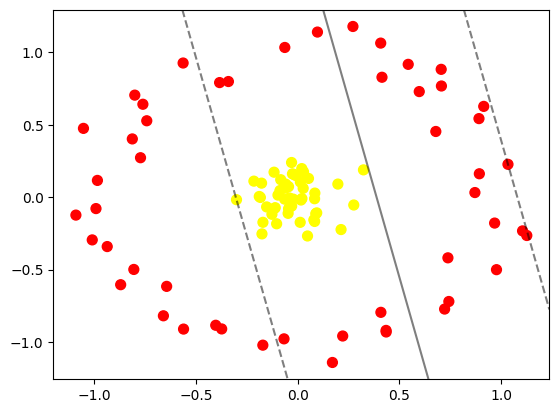

In [21]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [23]:
r = np.exp(-(X**2).sum(1))

In [24]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-1.01075269, -0.29525171],
       [ 0.87095063,  0.03186778],
       [ 0.02025131, -0.00985577],
       [-0.17615975, -0.25363078],
       [-0.06387071,  1.03424851],
       [-0.06773335, -0.97889229],
       [ 0.27528548, -0.05417241],
       [ 0.07892707, -0.15656947],
       [ 0.01175789, -0.17382528],
       [ 0.09307745, -0.10853283],
       [-0.03064606,  0.23944573],
       [-0.56176676, -0.91139217],
       [-0.08387451,  0.12065474],
       [-0.17188931, -1.02249098],
       [ 0.17031838, -1.14211847],
       [-0.1109598 , -0.07301475],
       [ 0.89278271,  0.16170887],
       [ 0.70513285,  0.88312692],
       [-0.11471282, -0.07646912],
       [ 0.54296042,  0.91762508],
       [-0.04535261, -0.07984152],
       [-0.11673454,  0.17251041],
       [-0.02611872,  0.16124637],
       [ 0.41399199,  0.82842982],
       [-0.74265225,  0.52781813],
       [-0.34116913,  0.79892733],
       [-0.9371318 , -0.34128941],
       [ 0.19705564,  0.09041828],
       [ 0.02645983,  0.06139437],
       [-0.06004315,  0.06342441],
       [-0.18941808,  0.00479943],
       [-0.08764398,  0.04568131],
       [ 0.04782258, -0.2681925 ],
       [-0.01027998,  0.15056817],
       [ 0.01566111, -0.01974109],
       [-0.0302788 , -0.06180449],
       [ 0.05259384,  0.12947165],
       [ 0.08261076, -0.01077033],
       [-0.12716947, -0.11835323],
       [-0.76176555,  0.64192918],
       [-0.80628974, -0.49938448],
       [ 0.21272023, -0.22382278],
       [ 0.01958646,  0.19725002],
       [-0.04756286, -0.11181422],
       [ 0.08834103, -0.11435599],
       [-1.05395062,  0.47521586],
       [-0.10404448, -0.18392672],
       [-0.66086157, -0.81960517],
       [ 0.70629159,  0.76803097],
       [-0.9853252 ,  0.11570838],
       [-0.04551039,  0.07259125],
       [-0.56389274,  0.92680483],
       [ 0.96794725, -0.17900738],
       [ 0.08275692, -0.16779661],
       [ 0.02812767,  0.17510817],
       [-0.03714184, -0.04839543],
       [ 0.09666216,  1.14065597],
       [ 0.72201182, -0.77303668],
       [-0.1840219 , -0.00190628],
       [-0.37424783, -0.91038236],
       [-0.0974158 ,  0.0144544 ],
       [ 0.40775529,  1.06438587],
       [-0.05904634,  0.08987936],
       [-0.8137392 ,  0.40236649],
       [ 0.91433557,  0.6272157 ],
       [ 0.27112017,  1.17922881],
       [-0.0409742 , -0.00570229],
       [-0.15319382, -0.06728974],
       [ 0.08393404,  0.0281122 ],
       [ 0.22082499, -0.95924279],
       [ 0.43467203, -0.93149625],
       [ 0.97713723, -0.50092297],
       [ 0.59723524,  0.72946006],
       [-0.0333482 , -0.01655969],
       [-0.77335171,  0.27250362],
       [-0.06453649, -0.01343489],
       [-0.40348579, -0.88503497],
       [-0.02232856, -0.01363772],
       [ 0.74280891, -0.72081656],
       [-0.99238765, -0.07889048],
       [-1.09116204, -0.12387795],
       [-0.87096795, -0.60476211],
       [ 1.1052565 , -0.2330319 ],
       [ 1.03352473,  0.22694205],
       [-0.17144745, -0.17367923],
       [ 0.43403377, -0.92061681],
       [ 0.67875235,  0.45374811],
       [ 0.8909336 ,  0.54274562],
       [-0.17813048,  0.09683057],
       [ 0.01261859,  0.10502286],
       [-0.80155315,  0.70488046],
       [-0.38445747,  0.79160702],
       [ 0.73823441, -0.41912606],
       [-0.01574838,  0.15450189],
       [ 0.32296708,  0.18856639],
       [-0.30135376, -0.01742966],
       [-0.64483816, -0.61632071],
       [ 0.40864007, -0.79565125],
       [-0.21583202,  0.11067068],
       [ 1.12613765, -0.26479422]]), y=array([0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0]))>

##Langkah 2 - Fitting Model

In [26]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

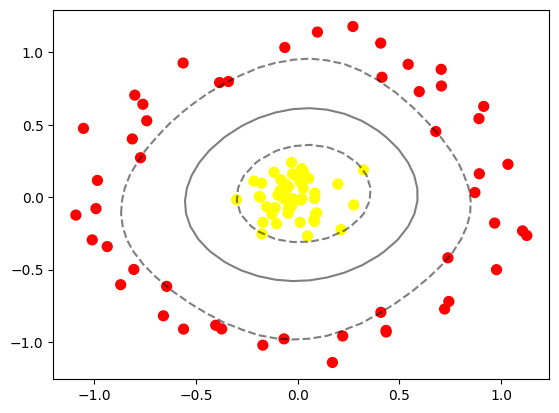

In [27]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')
